In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_rows', 1000)

op="compress"

current_path = os.getcwd()
directory = os.path.join(current_path) + "/../data/"
print(directory)
tot_dataframe = pd.DataFrame()
for root,dirs,files in os.walk(directory):
    for file in files:
       if (file.endswith(".csv")) and (op in file):
          csv_path=directory+file
          print(csv_path)
          data = pd.read_csv(csv_path)
          df = pd.DataFrame(data)
          tot_dataframe = pd.concat([tot_dataframe,df])

input_size = tot_dataframe['size'] * 2 + tot_dataframe['size'] # As I need to take as input a vector of SIZE elements of half, and a vector of INT8, hence size * 3
output_size = tot_dataframe['size'] * 4 # The output is in float, hence SIZE elements of 32 bits
tot_dataframe['mem_bytes'] = (tot_dataframe['size'] * (2 + 1))  + tot_dataframe['size'] * 4
print(tot_dataframe)

tot_dataframe['bandwidth_mbps'] = (tot_dataframe['mem_bytes']) / (tot_dataframe['time_us']) #MB/s


/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/
/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_compress_32_fp32.csv
/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_compress_128_fp32.csv
/scratch/gsorrentino/tcuscan/tmp_compress_profile_integration/pytorch-tcuscan/paper-plots/../data/bench_results_compress_64_fp32.csv
        operator dtype      size  time_us  mem_bytes
0    compress_32  fp32     20480    84.30     143360
1    compress_32  fp32   1331200   190.47    9318400
2    compress_32  fp32   2641920   302.00   18493440
3    compress_32  fp32   3952640   414.64   27668480
4    compress_32  fp32   5263360   518.61   36843520
5    compress_32  fp32   6574080   628.24   46018560
6    compress_32  fp32   7884800   739.38   55193600
7    compress_32  fp32   9195520   850.54   64368640
8    compress_32  fp32  

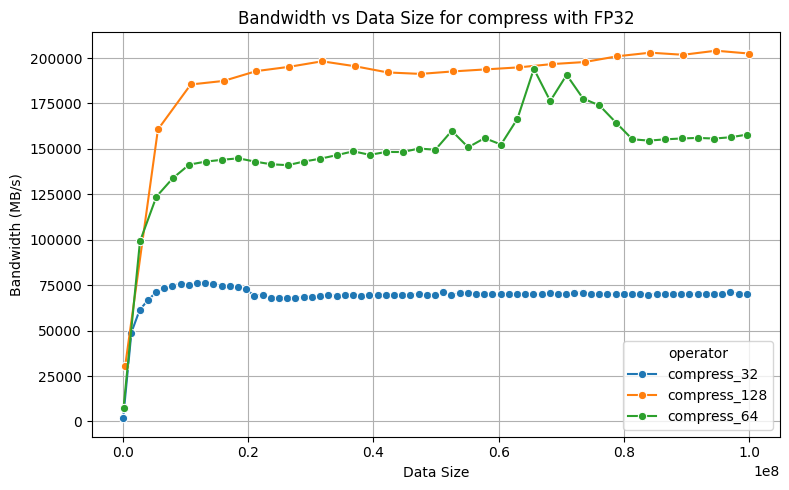

In [ ]:
plt.figure(figsize=(8, 5))

#I need to take the S from the name
sns.lineplot(x='size', y='bandwidth_mbps', hue='operator', data=tot_dataframe, marker='o')

plt.xlabel('Data Size')
plt.ylabel('Bandwidth (MB/s)')
dtype = tot_dataframe['dtype'].tolist()
title = 'Bandwidth vs Data Size for ' + str(op) + ' with ' +  dtype[0]
plt.title(title)
plt.tight_layout()

plt.grid(True)
filename = op + ".pdf"
plt.savefig(filename)
plt.show()
